In [91]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv; load_dotenv()

# Hyperparamyters
BASE_PATH = os.getenv("BASE_PATH_FOR_SAVING")
SAMPLE_ID = "sample_12"
BCL = "260721_SL-EXB_0892_B23Y3GKLT4" # 251027_SL-EXD_0706_A233KGFLT4 260313_SL-EXA_0758_B23GHNHLT4 
LIBRARY = "SI-TT-H3"

IS_SPATIAL = True  # Set True for slide-tag libraries, False for seq-only


In [92]:
os.path.join(BASE_PATH, "SlideTags_single_libraries", SAMPLE_ID, BCL, LIBRARY, "slide_tags")

'/home/gdallagl/myworkdir/data/XDP/SlideTags_single_libraries/sample_12/260721_SL-EXB_0892_B23Y3GKLT4/SI-TT-H3/slide_tags'

# 0. From BCL to Count Matrix

After sequencing, you must have run
1) all pipeline to get count matrix --> cellranger, slidetags postioning, ...
2) run cellbender to remove ambient rna [https://docs.google.com/document/d/1EbpN-GFM6xzYTmJRzb6d-8zTW8PVqgiJVurP5kREU7s/edit?tab=t.0]


*) copy from Terra bucket to macoko bucket: 
`gsutil cp "gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/slide-tags/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-B10/summary.pdf" "gs://macosko_data/gdallagl/XDP/second_3_xdp_samples/SI-TT-B10/summary.pdf"`

# 1. Make raw adata object
## 1.1 Copy data from Google Bucket (Terra) to here

In [93]:
# slide tags counts
if IS_SPATIAL:
    # ATTENTION:
    # it coudl be .qs or .qs2
    !gsutil cp gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/slide-tags/{BCL}/{LIBRARY}/seurat.qs {os.path.join(BASE_PATH, "SlideTags_dataset", "SlideTags_single_libraries", SAMPLE_ID, BCL, LIBRARY, "slide_tags")}
    !gsutil cp gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/slide-tags/{BCL}/{LIBRARY}/seurat.qs2 {os.path.join(BASE_PATH, "SlideTags_dataset", "SlideTags_single_libraries", SAMPLE_ID, BCL, LIBRARY, "slide_tags")}

# cell bender counts
!gsutil cp gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/gene-expression/{BCL}/{LIBRARY}/cellbender/{LIBRARY}/{LIBRARY}_out_filtered.h5 {os.path.join(BASE_PATH, "SlideTags_dataset", "SlideTags_single_libraries", SAMPLE_ID, BCL, LIBRARY, "cellbender")}

# dropsift qc metrics
!gsutil cp gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/gene-expression/{BCL}/{LIBRARY}/dropsift_outputs/dropsift_output.csv {os.path.join(BASE_PATH, "SlideTags_dataset", "SlideTags_single_libraries", SAMPLE_ID, BCL, LIBRARY, "dropsift")}



CommandException: No URLs matched: gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/slide-tags/260721_SL-EXB_0892_B23Y3GKLT4/SI-TT-H3/seurat.qs
Copying gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/slide-tags/260721_SL-EXB_0892_B23Y3GKLT4/SI-TT-H3/seurat.qs2...
| [1 files][298.3 MiB/298.3 MiB]                                                
Operation completed over 1 objects/298.3 MiB.                                    
Copying gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/gene-expression/260721_SL-EXB_0892_B23Y3GKLT4/SI-TT-H3/cellbender/SI-TT-H3/SI-TT-H3_out_filtered.h5...
\ [1 files][ 98.6 MiB/ 98.6 MiB]                                                
Operation completed over 1 objects/98.6 MiB.                                     
Copying gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/gene-expression/260721_SL-EXB_0892_B23Y3GKLT4/SI-TT-H3/dropsift_outputs/dropsift_output.csv...
/ [1 files][ 21.4 MiB/ 21.4 MiB]                                                
Oper

## 1.2 Install: R dependecies, R, qs library
Needed to convert .qs file into h5ad
- Install R dependencies
```bash
sudo apt-get install -y \
    build-essential \
    libhdf5-dev \
    libzstd-dev \
    liblz4-dev \
    libxxhash-dev \
    libcurl4-openssl-dev \
    libssl-dev \
    libxml2-dev \
    zlib1g-dev
```

- Install R
```bash
sudo apt-get install r-base r-base-dev
 ```

- install qs library
 ```R
install.packages("qs")
 ```

# 2. Extract metadata (x,y) from slidetags .qs file

In [94]:
cwd = os.getcwd()
print(cwd)
slide_tags_folder = f"{BASE_PATH}/SlideTags_dataset/SlideTags_single_libraries/{SAMPLE_ID}/{BCL}/{LIBRARY}/slide_tags/"

%cd {slide_tags_folder}

/home/gdallagl/myworkdir/XDP/script/SlideTags_XDP_preprocessing
/home/gdallagl/myworkdir/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_12/260721_SL-EXB_0892_B23Y3GKLT4/SI-TT-H3/slide_tags


In [95]:
if IS_SPATIAL:
    
    # %%bash
    # R --vanilla << 'EOF'
    # library(qs)

    # # Read the Seurat object
    # seurat <- qread("./seurat.qs")

    # # Extract and save just the metadata
    # metadata <- seurat@meta.data
    # write.csv(metadata, "./seurat_metadata.csv", row.names = TRUE)

    import subprocess

    r_code = (
        'if (file.exists("./seurat.qs2")) { '
        '        library(qs2); '
        '        seurat <- qs2::qs_read("./seurat.qs2"); '
        '        metadata <- seurat@meta.data; '
        '        write.csv(metadata, "./seurat_metadata.csv", row.names = TRUE); '
        '} else if (file.exists("./seurat.qs")) { '
        '        library(qs); '
        '        seurat <- qs::qread("./seurat.qs"); '
        '        metadata <- seurat@meta.data; '
        '        write.csv(metadata, "./seurat_metadata.csv", row.names = TRUE); '
        '}'
)

    result = subprocess.run(
        ["Rscript", "--vanilla", "-e", r_code],
        cwd=slide_tags_folder,
        capture_output=True,
        text=True,
    )
    print(result.stdout)
    print(result.stderr)



qs2 0.2.2



In [96]:
%cd {cwd}

/home/gdallagl/myworkdir/XDP/script/SlideTags_XDP_preprocessing


# Read DropSift Qc metrics

In [97]:
df_dropsift = pd.read_csv(f"{BASE_PATH}/SlideTags_dataset/SlideTags_single_libraries/{SAMPLE_ID}/{BCL}/{LIBRARY}/dropsift/dropsift_output.csv")
if "is_cell" in df_dropsift.columns:
    df_dropsift.rename(columns={"is_cell": "is_cell_dropsift"}, inplace=True)
else:
    df_dropsift["is_cell_dropsift"] = np.where(df_dropsift["barcode_class"] == "nucleus", True, False)
display(df_dropsift.head())
df_dropsift["barcode_class"].value_counts()


,cell_barcode,num_transcripts,pct_intronic,pct_mt,frac_contamination,num_retained_transcripts,training_label_class,empty_gene_module_score,debris_gene_module_score,p_nucleus_vs_empty,p_nucleus_vs_debris,is_cell_prob,p_debris_vs_nucleus,p_debris_vs_empty,is_debris_prob,barcode_class,is_cell_dropsift
0,AAACCAAAGACATCCA-1,102,0.509804,0.009804,1.000000,0,empty,-0.032566,NaN,0.000011,NaN,NaN,NaN,NaN,NaN,NaN,False
1,AAACCAAAGACCACGT-1,74,0.472973,0.013514,1.000000,0,NaN,0.074047,NaN,0.000011,NaN,NaN,NaN,NaN,NaN,NaN,False
2,AAACCAAAGACCCATA-1,11,0.636364,0.000000,1.000000,0,NaN,-0.003804,NaN,0.000302,NaN,NaN,NaN,NaN,NaN,NaN,False
3,AAACCAAAGACGTGTC-1,30634,0.744434,0.001893,0.007769,30396,nucleus,-0.275031,NaN,0.999921,NaN,0.999921,NaN,NaN,NaN,nucleus,True
4,AAACCAAAGAGGCACA-1,113,0.504425,0.035398,1.000000,0,empty,0.104278,NaN,0.000013,NaN,NaN,NaN,NaN,NaN,NaN,False


barcode_class
empty_or_other    16332
nucleus            9743
Name: count, dtype: int64

# Read metadat Slidetag

In [98]:
if IS_SPATIAL:
    metadata_slidetags = pd.read_csv(f"{BASE_PATH}/SlideTags_dataset/SlideTags_single_libraries/{SAMPLE_ID}/{BCL}/{LIBRARY}/slide_tags/seurat_metadata.csv").rename(columns={"Unnamed: 0": "barcode"})
    metadata_slidetags.rename(columns={"is_cell": "is_cell_slidetag", "barcode": "cell_barcode"}, inplace=True)
    display(metadata_slidetags.head())

,cell_barcode,orig.ident,nCount_RNA,nFeature_RNA,is_cell_slidetag,pct_intronic,pct_mt,RNA_snn_res.0.8,seurat_clusters,x,y,dbscan_clusters,dbscan_score
0,AAACCAAAGACGTGTC-1,Slide-tags,30634,6967,True,0.744434,0.001893,3,3,42488.180547,-12833.020943,1,0.990346
1,AAACCAAAGCAAGACG-1,Slide-tags,32632,6996,True,0.763851,0.000674,0,0,12453.534464,580.834217,1,0.991911
2,AAACCAAAGGTATCCA-1,Slide-tags,45654,8363,True,0.738928,0.007097,3,3,46780.570957,-10308.346718,1,0.980442
3,AAACCAGCAACTTTAG-1,Slide-tags,55790,9701,True,0.683510,0.001667,18,18,53915.408114,-6411.642453,2,0.234618
4,AAACCAGCACCCAAAT-1,Slide-tags,18998,5881,True,0.641804,0.000474,6,6,32677.630797,-3856.391110,1,0.978677


# Read Count matrix from CellBender

In [99]:
# 1. Load CellBender cleaned counts
adata_cb = sc.read_10x_h5(f"{BASE_PATH}/SlideTags_dataset/SlideTags_single_libraries/{SAMPLE_ID}/{BCL}/{LIBRARY}/cellbender/{LIBRARY}_out_filtered.h5")
print(adata_cb)
display(adata_cb.var)
adata_cb.obs

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 10531 × 38606
    var: 'gene_ids', 'feature_types', 'genome'


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


,gene_ids,feature_types,genome
DDX11L2,ENSG00000290825,Gene Expression,GRCh38
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38
FAM138A,ENSG00000237613,Gene Expression,GRCh38
ENSG00000290826,ENSG00000290826,Gene Expression,GRCh38
OR4F5,ENSG00000186092,Gene Expression,GRCh38
...,...,...,...
ENSG00000277836,ENSG00000277836,Gene Expression,GRCh38
ENSG00000278633,ENSG00000278633,Gene Expression,GRCh38
ENSG00000276017,ENSG00000276017,Gene Expression,GRCh38
ENSG00000278817,ENSG00000278817,Gene Expression,GRCh38


""
CGCATCACAAACTAGG-1
GCTGTATCACACTCGA-1
ATACTCCTCGCGGAAA-1
AAAGTTCTCCGTTCGC-1
ATCGATTAGGTATTCG-1
...
GCAACAGAGCGCAGTT-1
GGTTCCGAGGCAGGGT-1
GCGACCTCAAACGAGC-1
AAGTCCGGTACAACGT-1


# Find barcode that are cells

Intersection:
- is cell by dropsfit
- is cell by slidetag
- (is cell by cell bdner --> we use its count matrix)

In [100]:
# Sets of cells
dropsift_cells = set(df_dropsift[df_dropsift["is_cell_dropsift"]]["cell_barcode"])
cellbender_cells = set(adata_cb.obs_names)

print(f"DropSift:   {len(dropsift_cells):>6} cells")
print(f"CellBender: {len(cellbender_cells):>6} cells")

if IS_SPATIAL:
    slidetags_cells = set(metadata_slidetags[metadata_slidetags["is_cell_slidetag"]]["cell_barcode"])
    final_cells = slidetags_cells & dropsift_cells & cellbender_cells
    print(f"SlideTags:  {len(slidetags_cells):>6} cells")
else:
    final_cells = dropsift_cells & cellbender_cells

print(f"Final (intersection): {len(final_cells):>6} cells")


DropSift:     9743 cells
CellBender:  10531 cells
SlideTags:    9475 cells
Final (intersection):   9457 cells


# 3. Create adata obj

- metadata --> from slidetags
- count matrix --> from cell bender

- ATTENTION: use cells present in both

In [101]:
# make adata obj

# Subset CellBender AnnData to intersection
adata = adata_cb[sorted(final_cells)].copy()

# Subset slidetag metadata to the same cells
    # .loc[adata.obs_names] explicitly indexes by adata.obs_names in the exact same order
if IS_SPATIAL:
    metadata_intersection = metadata_slidetags.set_index("cell_barcode").loc[adata.obs_names]
    assert (metadata_intersection.index == adata.obs_names).all(), "Index mismatch!"
    # Add slidetag metadata into AnnData obs
    adata.obs = adata.obs.join(metadata_intersection)

else:
    # Add placeholder columns so downstream code is uniform
    adata.obs["x"] = np.nan
    adata.obs["y"] = np.nan
    adata.obs["dbscan_clusters"] = np.nan
    adata.obs["dbscan_score"] = np.nan

# overwirte 
adata.obs["pct_intronic"] = df_dropsift.set_index("cell_barcode")["pct_intronic"].reindex(adata.obs_names).values
adata.obs["frac_contamination"] = df_dropsift.set_index("cell_barcode")["frac_contamination"].reindex(adata.obs_names).values

# Change var names as MapMyCell works with ensemblID
adata.var['gene_symbol'] = adata.var.index # Save current index (gene symbols) to a new column
adata.var.set_index('gene_ids', inplace=True) # Set the 'gene_ids' column as the new index
adata.var.index.name = 'ensembl_id' #rename the index

print(adata)
display(adata.obs)
display(adata.var)

AnnData object with n_obs × n_vars = 9457 × 38606
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'is_cell_slidetag', 'pct_intronic', 'pct_mt', 'RNA_snn_res.0.8', 'seurat_clusters', 'x', 'y', 'dbscan_clusters', 'dbscan_score', 'frac_contamination'
    var: 'feature_types', 'genome', 'gene_symbol'


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


,orig.ident,nCount_RNA,nFeature_RNA,is_cell_slidetag,pct_intronic,pct_mt,RNA_snn_res.0.8,seurat_clusters,x,y,dbscan_clusters,dbscan_score,frac_contamination
AAACCAAAGACGTGTC-1,Slide-tags,30634,6967,True,0.744434,0.001893,3,3,42488.180547,-12833.020943,1,0.990346,0.007769
AAACCAAAGCAAGACG-1,Slide-tags,32632,6996,True,0.763851,0.000674,0,0,12453.534464,580.834217,1,0.991911,0.007140
AAACCAAAGGTATCCA-1,Slide-tags,45654,8363,True,0.738928,0.007097,3,3,46780.570957,-10308.346718,1,0.980442,0.002760
AAACCAGCAACTTTAG-1,Slide-tags,55790,9701,True,0.683510,0.001667,18,18,53915.408114,-6411.642453,2,0.234618,0.002258
AAACCAGCACCCAAAT-1,Slide-tags,18998,5881,True,0.641804,0.000474,6,6,32677.630797,-3856.391110,1,0.978677,0.041583
...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTTGTCTTCGTTCTAC-1,Slide-tags,24483,6908,True,0.759874,0.000572,9,9,35002.539607,-2215.668368,1,0.996100,0.020218
GTTGTGCAGATCACAT-1,Slide-tags,43464,8063,True,0.774319,0.000828,3,3,9228.794116,1053.109411,1,0.995154,0.003589
GTTGTGGGTACCATCC-1,Slide-tags,38065,7775,True,0.756758,0.000184,5,5,26039.976024,141.914384,1,0.958534,0.004361
GTTGTGGGTCATACTT-1,Slide-tags,148819,12951,True,0.743346,0.001364,4,4,47745.124273,-9436.079408,7,0.290273,0.000417


,feature_types,genome,gene_symbol
ensembl_id,,,
ENSG00000290825,Gene Expression,GRCh38,DDX11L2
ENSG00000243485,Gene Expression,GRCh38,MIR1302-2HG
ENSG00000237613,Gene Expression,GRCh38,FAM138A
ENSG00000290826,Gene Expression,GRCh38,ENSG00000290826
ENSG00000186092,Gene Expression,GRCh38,OR4F5
...,...,...,...
ENSG00000277836,Gene Expression,GRCh38,ENSG00000277836
ENSG00000278633,Gene Expression,GRCh38,ENSG00000278633
ENSG00000276017,Gene Expression,GRCh38,ENSG00000276017


### Little checks

In [102]:
# Check 1: Shape (cells × genes)
print(f"Shape: {adata.shape}")  # Should be (n_cells, n_genes)

# Check 2: Are counts integers/raw?
print(f"Max value: {adata.X.max()}")  # Should be reasonable count values
print(f"Data type: {adata.X.dtype}")  # Should be integer-like

# Check 3: Gene IDs are Ensembl?
print(adata.var.index[:5])  # Should start with 'ENSG' for human

# Check 4: No NaN or negative values
print(f"Contains NaN: {pd.isna(adata.X.data).any()}")  # Should be False
print(f"Min value: {adata.X.min()}")  # Should be >= 0

# Check 5: Duplicate gene IDs
gene_duplicates = adata.var.index.duplicated()
n_gene_duplicates = gene_duplicates.sum()
print(f"Duplicate genes: {n_gene_duplicates}")
if n_gene_duplicates > 0:
    print(f"⚠️  Duplicate gene IDs found: {adata.var.index[gene_duplicates].tolist()[:10]}")



Shape: (9457, 38606)
Max value: 13898
Data type: int64
Index(['ENSG00000290825', 'ENSG00000243485', 'ENSG00000237613',
       'ENSG00000290826', 'ENSG00000186092'],
      dtype='object', name='ensembl_id')
Contains NaN: False
Min value: 0
Duplicate genes: 0


# 4. Remove no more correct metadata

As we use the count matrix from cell bender, some QC metrics calculated from slidetags are no more correct.

In [103]:
# Remove qc metric columns that are no more correct after using cell itersection
    # ATTNETION: pct_intronic --> not totally correct, but lets leave it
adata.obs = adata.obs[["x", "y", "pct_intronic", "frac_contamination", "dbscan_clusters", "dbscan_score"]]

# Save raw counts
adata.layers["counts"] = adata.X.copy()

# Save sample
adata.obs["sample"] = SAMPLE_ID


# Add spatial obsm

ATTNETION: cell has spail x,y if dbcluster_lcuster == 1

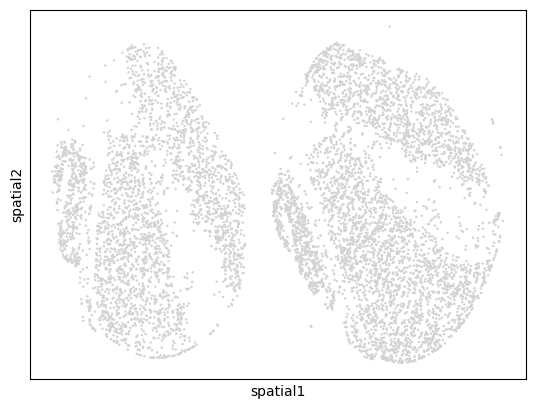

AnnData object with n_obs × n_vars = 9457 × 38606
    obs: 'x', 'y', 'pct_intronic', 'frac_contamination', 'dbscan_clusters', 'dbscan_score', 'sample', 'has_spatial'
    var: 'feature_types', 'genome', 'gene_symbol'
    obsm: 'spatial'
    layers: 'counts'

In [104]:
# Add spatila data
    # ATTENTION: adata.obs.dbscan_clusters == 1
if IS_SPATIAL:
    adata.obs["has_spatial"] = (~adata.obs.x.isna()) & (~adata.obs.y.isna()) & (adata.obs.dbscan_clusters == 1)
else:
    adata.obs["has_spatial"] = False

# Add spaitla bsm
    # Create spatial matrix with NaN by default
spatial_coords = np.full((adata.n_obs, 2), np.nan)
    # For cells with has_spatial == True, add their real coordinates
mask = adata.obs['has_spatial']
spatial_coords[mask] = adata.obs.loc[mask, ['x', 'y']].values
    # Assign to obsm
adata.obsm['spatial'] = spatial_coords

# Plot
sc.pl.embedding(adata, basis="spatial")#, color="nCount_RNA")

display(adata)

# 4. Save

In [105]:
SAVE_PATH = f"{BASE_PATH}/SlideTags_dataset/SlideTags_single_libraries/{SAMPLE_ID}/{BCL}/{LIBRARY}/adata/raw_adata.h5ad"
adata.write(SAVE_PATH)
SAVE_PATH

'/home/gdallagl/myworkdir/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_12/260721_SL-EXB_0892_B23Y3GKLT4/SI-TT-H3/adata/raw_adata.h5ad'